In [3]:
# 匯入需套件
import joblib
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# 載入包含 CatBoost 模型及 SHAP 分析資料的完整檔案
shap_bundle = joblib.load(
    "Model_1_Results_include/SHAP_Complete_Bundle.pkl"
)
# 從檔案中分別取得最終模型、訓練集、內部測試集及外部驗證集
cat_clf_final = shap_bundle["cat_model"]
X_cat_train_final = shap_bundle["X_train_smotenc"]
X_cat_test_scaled = shap_bundle["X_internal"]
X_external_scaled = shap_bundle["X_external"]

print("CatBoost 模型與三組 SHAP 資料已載入")

CatBoost 模型與三組 SHAP 資料已載入


In [4]:
# 自訂特徵名稱
custom_feature_names = [
    "Age", "Pre-BMI", "BMI change", "Pre-SMI",
    "Sex", "ECOG", "Tumor site", "Stage",
    "Chemotherapy", "Smoking", "Dermatitis",
    "Mucositis", "Xerostomia", "Dysphagia",
    "Pain", "Anorexia", "Nausea", "Fatigue",
]

# CatBoost SHAP importance plot

In [5]:
# 計算並繪製 CatBoost 模型的 SHAP 特徵重要性
def plot_catboost_shap_importance(explainer,X,feature_names,title,xlim=(0, 1.15),xticks=np.arange(0, 1.1, 0.2),save_path=None):
    # 將輸入資料轉換為 DataFrame，並套用自訂特徵名稱
    X_shap = pd.DataFrame(
        np.asarray(X),
        columns=feature_names,
    )
     # 計算每筆樣本及每項特徵的 SHAP 值
    shap_values = explainer(X_shap)
    # 計算各特徵 SHAP 絕對值的平均值，作為整體特徵重要性
    shap_importance = np.abs(shap_values.values).mean(axis=0)
     # 將特徵名稱及重要性由高至低排序
    shap_df = pd.DataFrame({
        "Feature": feature_names,
        "Mean |SHAP value|": shap_importance,
    }).sort_values(
        by="Mean |SHAP value|",
        ascending=False,
    )
    # 建立水平長條圖
    plt.figure(figsize=(8, 6))
    plt.barh(
        shap_df["Feature"],
        shap_df["Mean |SHAP value|"],
        color="#0099FF",
        edgecolor="none",
    )

    plt.gca().invert_yaxis()
    plt.yticks(fontsize=11)
    plt.xticks(xticks, fontsize=10)
    plt.xlim(*xlim)
    plt.xlabel(
        "mean(|SHAP value|) (average impact on model output magnitude)",
        fontsize=11,
    )
    plt.title(title, fontsize=14)
    plt.axvline(x=0, linestyle="-", color="gray", alpha=0.5)
    plt.grid(False)

    ax = plt.gca()
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["left"].set_visible(False)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

    return shap_values, shap_df

In [6]:
# 建立CatBoost explainer
cat_explainer = shap.TreeExplainer(
    cat_clf_final
)

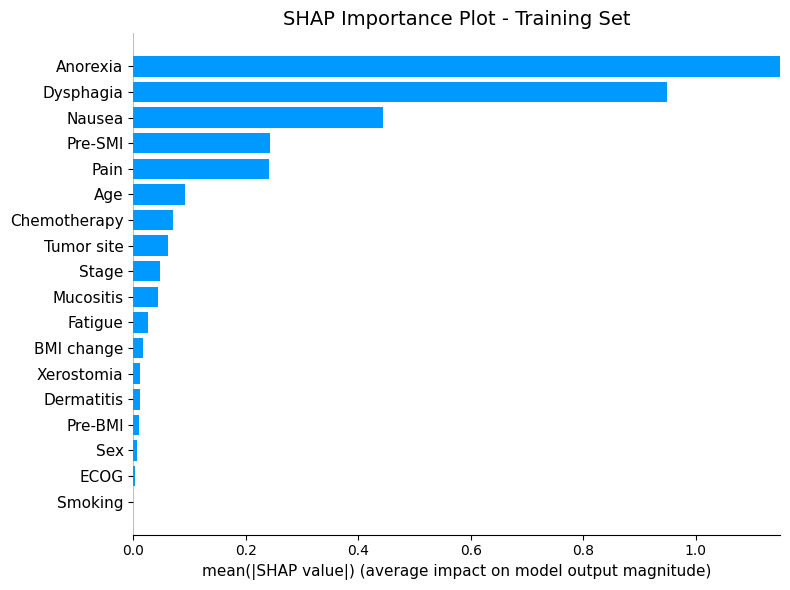

In [7]:
# Training Set
shap_values_train, shap_df_train = (
    plot_catboost_shap_importance(
        explainer=cat_explainer,
        X=X_cat_train_final,
        feature_names=custom_feature_names,
        title="SHAP Importance Plot - Training Set",
    )
)

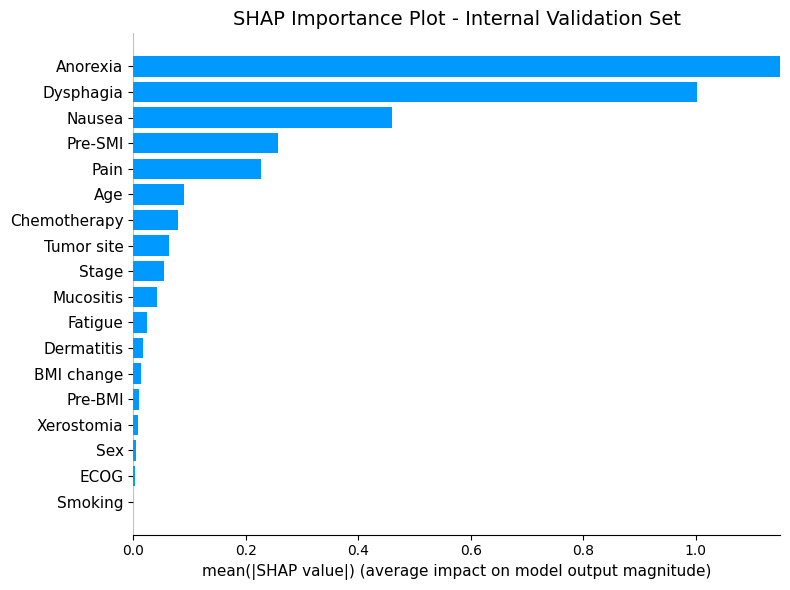

In [8]:
# Internal Validation Set
shap_values_intest, shap_df_intest = (
    plot_catboost_shap_importance(
        explainer=cat_explainer,
        X=X_cat_test_scaled,
        feature_names=custom_feature_names,
        title="SHAP Importance Plot - Internal Validation Set",
    )
)

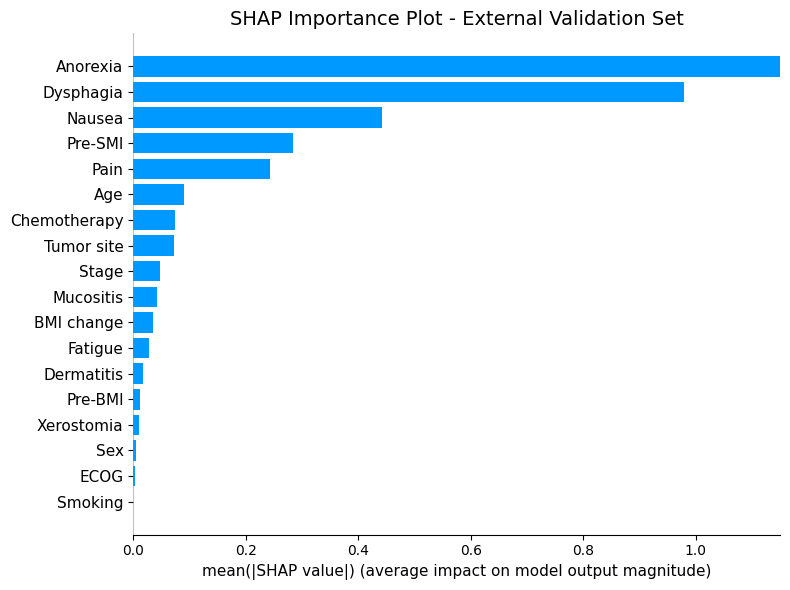

In [9]:
# External Validation Set
shap_values_external, shap_df_external = (
    plot_catboost_shap_importance(
        explainer=cat_explainer,
        X=X_external_scaled,
        feature_names=custom_feature_names,
        title="SHAP Importance Plot - External Validation Set",
    )
)

# catboost beeswarm plot

In [11]:
# 繪製 CatBoost 模型的 SHAP Beeswarm 圖
def plot_catboost_beeswarm(shap_values, title, feature_names=custom_feature_names,
                           x_min=-2.0, x_max=2.0, tick_interval=0.5, save_path=None):
    # 檢查 SHAP 特徵數量是否與指定的特徵名稱數量一致
    if shap_values.values.shape[1] != len(feature_names):
        raise ValueError(f"SHAP 特徵數量為 {shap_values.values.shape[1]}，但 feature_names 有 {len(feature_names)} 個")
    # 將自訂特徵名稱設定至 SHAP 結果中
    shap_values.feature_names = list(feature_names)
    # 繪圖
    shap.plots.beeswarm(shap_values, max_display=len(feature_names), show=False)

    plt.gcf().suptitle(title, fontsize=14)
    plt.xlim(x_min, x_max)
    plt.xticks(np.arange(x_min, x_max + 0.1, tick_interval))
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

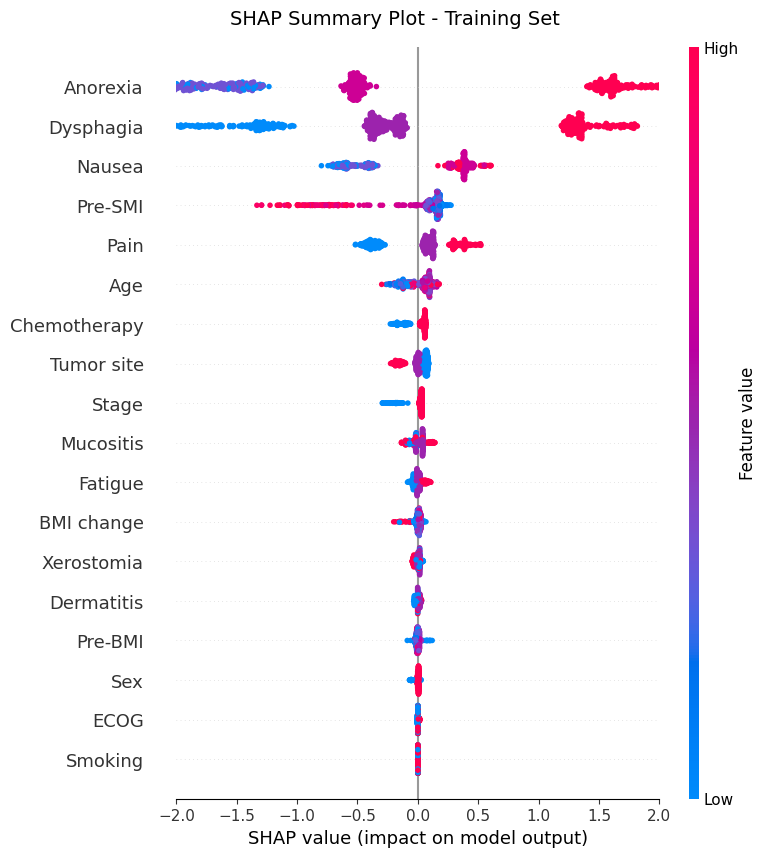

In [12]:
# Training Set
plot_catboost_beeswarm(
    shap_values=shap_values_train,
    title="SHAP Summary Plot - Training Set",
)

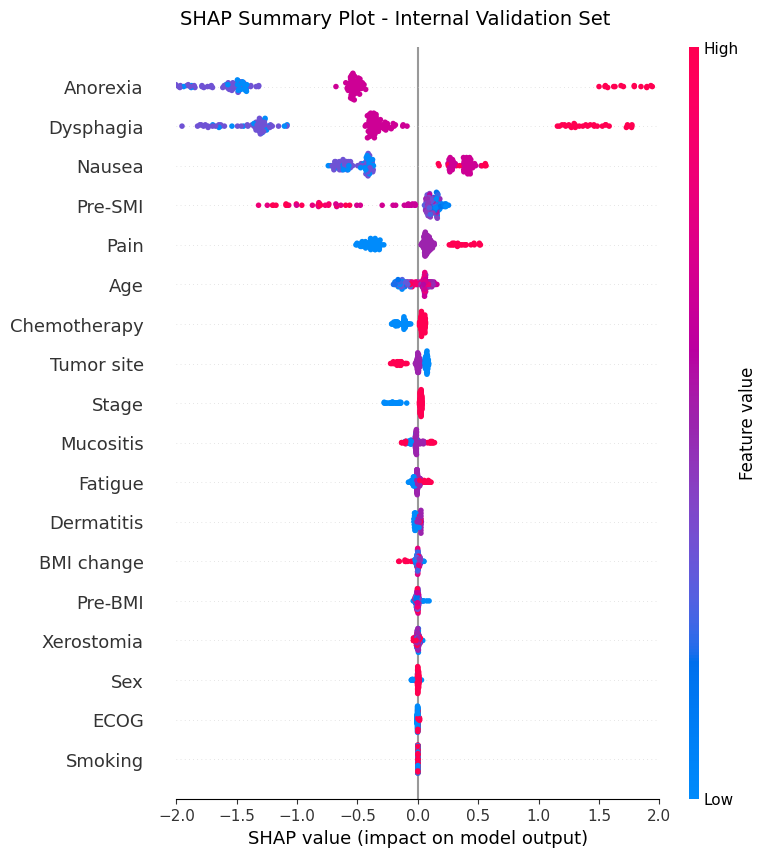

In [13]:
# Internal Validation Set
plot_catboost_beeswarm(
    shap_values=shap_values_intest,
    title="SHAP Summary Plot - Internal Validation Set",
)

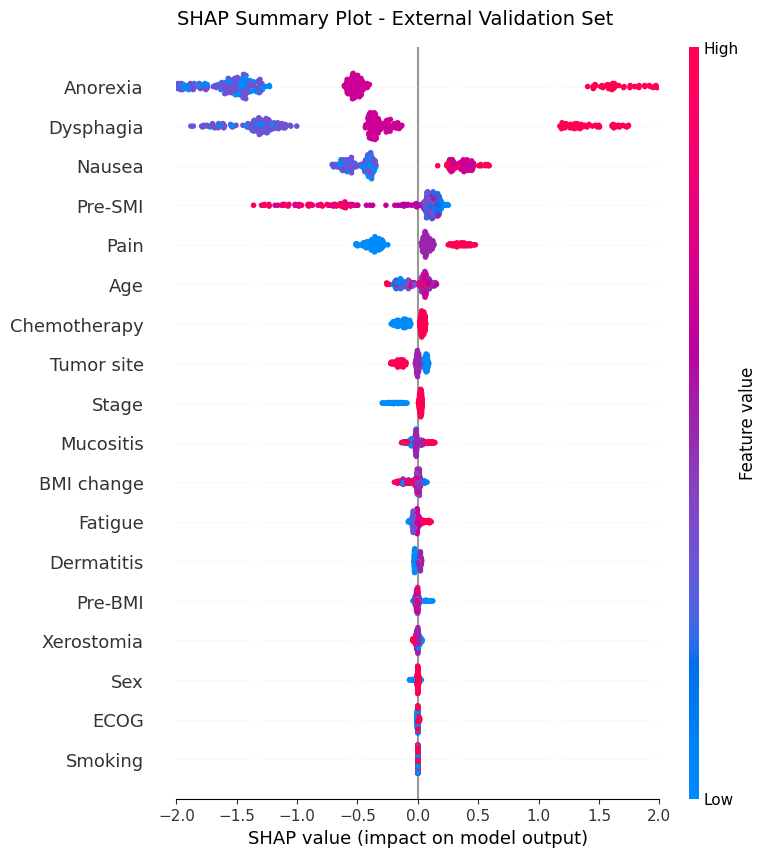

In [14]:
# External Validation Set
plot_catboost_beeswarm(
    shap_values=shap_values_external,
    title="SHAP Summary Plot - External Validation Set",
)

# catboost SHAP dependence plot

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
# 繪製指定特徵的 CatBoost SHAP dependence plot
def plot_catboost_dependence(shap_values, raw_values, feature_name, title, x_label,
                             feature_type="continuous", xlim=None, ylim=None,
                             xticks=None, yticks=None, xtick_labels=None,
                             category_ticks=None, category_labels=None,
                             colorbar_label=None, figsize=(8, 6), save_path=None):
    # 取得 SHAP 資料中的特徵名稱，並確認指定特徵存在
    feature_names = list(shap_values.feature_names)
    if feature_name not in feature_names:
        raise ValueError(f"{feature_name} 不在 SHAP 特徵中：{feature_names}")
    # 將指定特徵的原始資料轉換為一維陣列
    raw_values = np.asarray(raw_values).ravel()
    if len(raw_values) > len(shap_values.values):
        raise ValueError(f"原始資料有 {len(raw_values)} 筆，但 SHAP 只有 {len(shap_values.values)} 筆")

    # Training SHAP 是 SMOTENC 資料時，自動只取前面的原始樣本
    feature_index = feature_names.index(feature_name)
    shap_feature_values = shap_values.values[:len(raw_values), feature_index]
    # 整理指定特徵的原始數值與其對應的 SHAP 值
    plot_df = pd.DataFrame({
        "raw_value": raw_values,
        "shap_value": shap_feature_values,
    })
    # 特徵顏色
    cmap_custom = LinearSegmentedColormap.from_list(
        "RedPurpleBlue", ["#0099FF", "#AA00AA", "#FF0055"]
    )
    # 建立圖表，並以特徵原始數值決定散點顏色
    fig, ax = plt.subplots(figsize=figsize)
    scatter = ax.scatter(
        plot_df["raw_value"], plot_df["shap_value"],
        c=plot_df["raw_value"], cmap=cmap_custom, s=20, edgecolors="none"
    )
    # 加入顏色
    cbar = plt.colorbar(scatter, ax=ax, aspect=70, pad=0.02, shrink=1.0)
    cbar.set_label(colorbar_label or x_label, fontsize=10)
    cbar.outline.set_visible(False)
    # 若為類別型特徵，設定顏色條上的類別刻度與標籤
    if feature_type == "categorical" and category_ticks is not None:
        cbar.set_ticks(category_ticks)
        cbar.set_ticklabels(category_labels or [str(x) for x in category_ticks])
    # 設定圖表標題及座標軸名稱
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(x_label, fontsize=12)
    ax.set_ylabel("SHAP value", fontsize=12)
    # 依照輸入參數調整座標範圍、刻度及刻度標籤
    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)
    if xticks is not None:
        ax.set_xticks(xticks)
    if yticks is not None:
        ax.set_yticks(yticks)
    if xtick_labels is not None:
        ax.set_xticklabels(xtick_labels)

    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.grid(False)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()
    return plot_df

In [21]:
# 從 bundle 取出未經 SMOTENC 的原始資料
X_train_raw = shap_bundle["X_train"]
X_internal_raw = shap_bundle["X_internal"]
X_external_raw = shap_bundle["X_external"]

continuous_cols = ["Age", "pre_BMI", "BMI_change", "pre_SMI"]

# 恢復舊變數名稱
X_train70_cont = X_train_raw[continuous_cols]
X_train70_cat = X_train_raw.drop(columns=continuous_cols)

X_test30_cont = X_internal_raw[continuous_cols]
X_test30_cat = X_internal_raw.drop(columns=continuous_cols)

external_cont = X_external_raw[continuous_cols]
external_cat = X_external_raw.drop(columns=continuous_cols)

print("原始 Train、Internal、External 特徵已建立")
print("Train:", X_train_raw.shape)
print("Internal:", X_internal_raw.shape)
print("External:", X_external_raw.shape)

✅ 原始 Train、Internal、External 特徵已建立
Train: (400, 18)
Internal: (172, 18)
External: (331, 18)


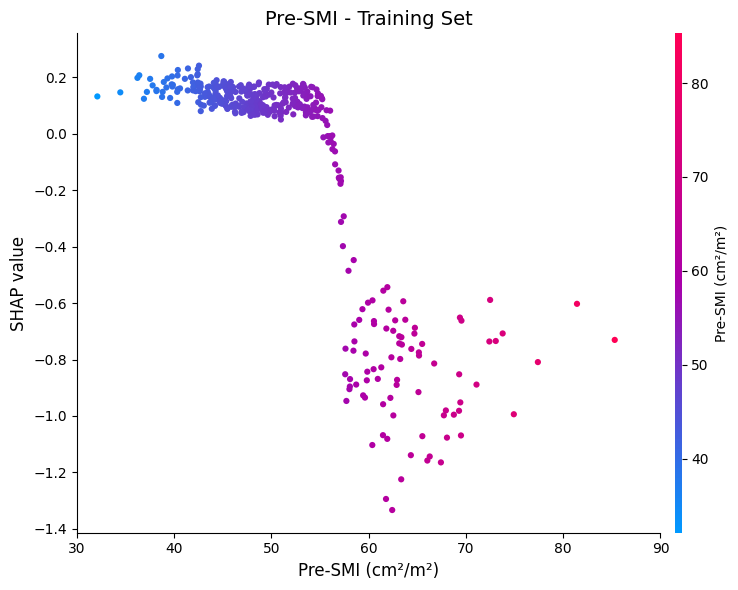

In [23]:
# Pre-SMI
presmi_train_df = plot_catboost_dependence(
    shap_values=shap_values_train,
    raw_values=X_train70_cont["pre_SMI"].values,
    feature_name="Pre-SMI",
    title="Pre-SMI - Training Set",
    x_label="Pre-SMI (cm²/m²)",
    feature_type="continuous",
    xlim=(30, 90),
    xticks=range(30, 91, 10),
)

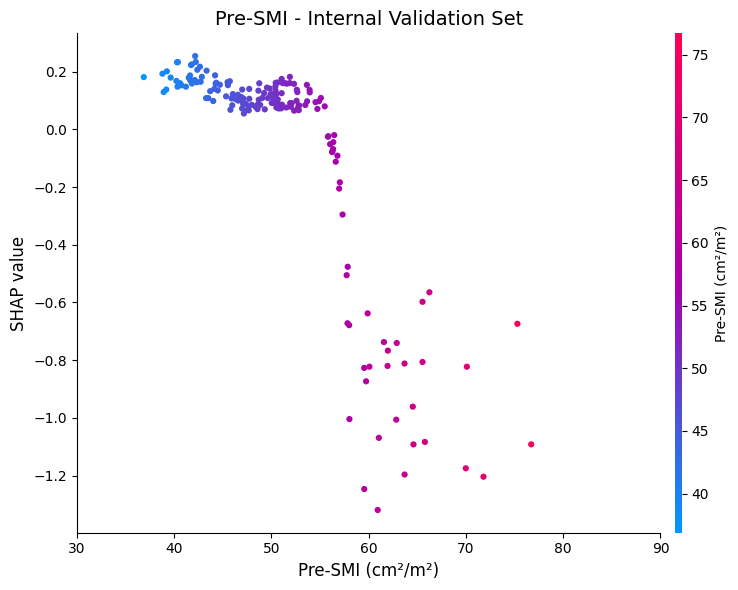

In [24]:
presmi_internal_df = plot_catboost_dependence(
    shap_values=shap_values_intest,
    raw_values=X_test30_cont["pre_SMI"].values,
    feature_name="Pre-SMI",
    title="Pre-SMI - Internal Validation Set",
    x_label="Pre-SMI (cm²/m²)",
    feature_type="continuous",
    xlim=(30, 90),
    xticks=range(30, 91, 10),
)

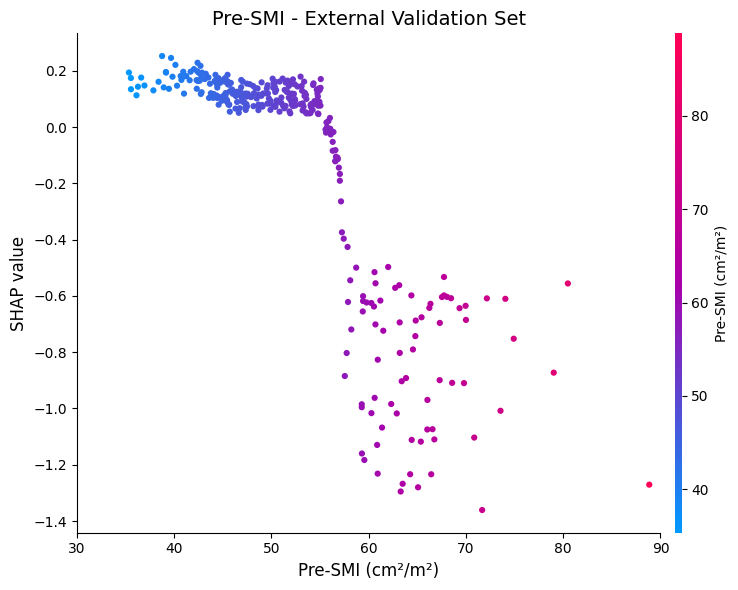

In [25]:
presmi_external_df = plot_catboost_dependence(
    shap_values=shap_values_external,
    raw_values=external_cont["pre_SMI"].values,
    feature_name="Pre-SMI",
    title="Pre-SMI - External Validation Set",
    x_label="Pre-SMI (cm²/m²)",
    feature_type="continuous",
    xlim=(30, 90),
    xticks=range(30, 91, 10),
)

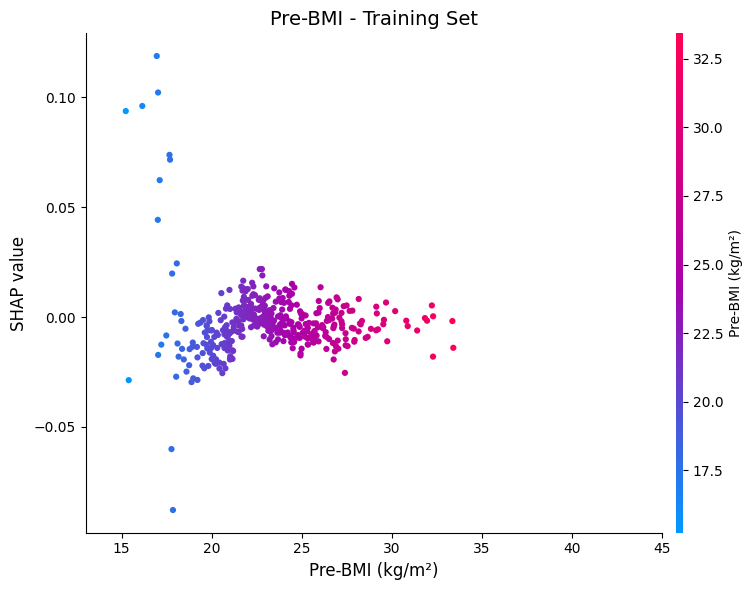

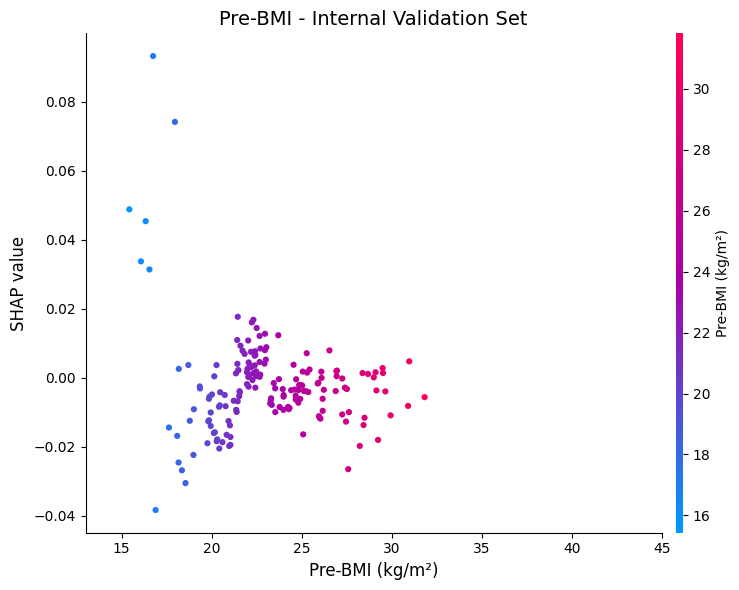

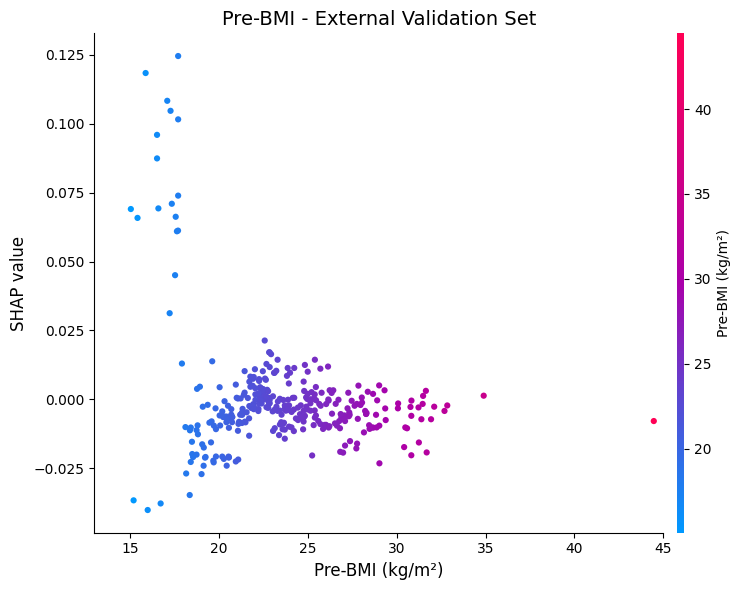

In [31]:
# Pre-BMI
prebmi_train_df = plot_catboost_dependence(
    shap_values=shap_values_train,
    raw_values=shap_bundle["X_train"]["pre_BMI"].values,
    feature_name="Pre-BMI",
    title="Pre-BMI - Training Set",
    x_label="Pre-BMI (kg/m²)",
    feature_type="continuous",
    xlim=(13, 45),
    xticks=range(15, 46, 5),
)


prebmi_internal_df = plot_catboost_dependence(
    shap_values=shap_values_intest,
    raw_values=shap_bundle["X_internal"]["pre_BMI"].values,
    feature_name="Pre-BMI",
    title="Pre-BMI - Internal Validation Set",
    x_label="Pre-BMI (kg/m²)",
    feature_type="continuous",
    xlim=(13, 45),
    xticks=range(15, 46, 5),
)

prebmi_external_df = plot_catboost_dependence(
    shap_values=shap_values_external,
    raw_values=shap_bundle["X_external"]["pre_BMI"].values,
    feature_name="Pre-BMI",
    title="Pre-BMI - External Validation Set",
    x_label="Pre-BMI (kg/m²)",
    feature_type="continuous",
    xlim=(13, 45),
    xticks=range(15, 46, 5),
)


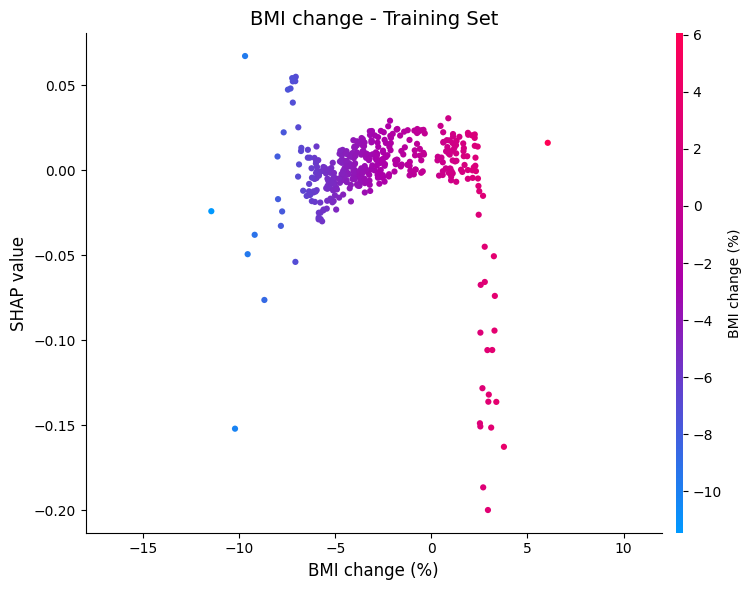

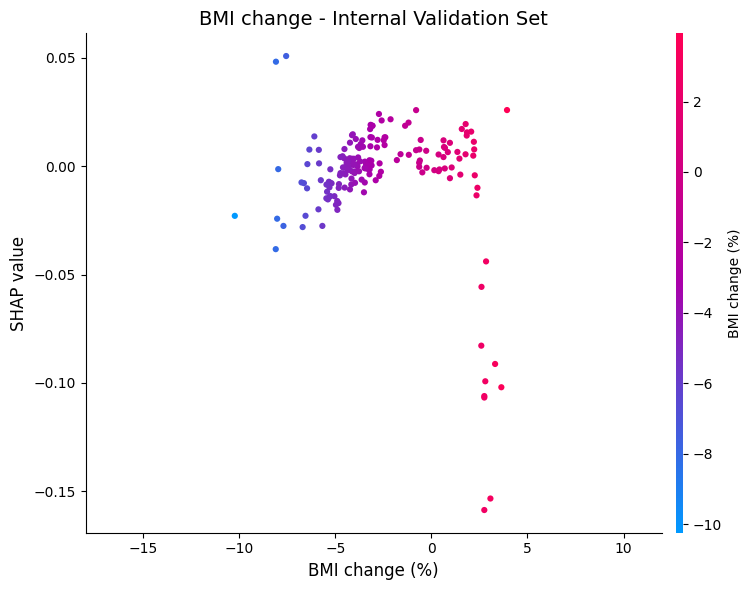

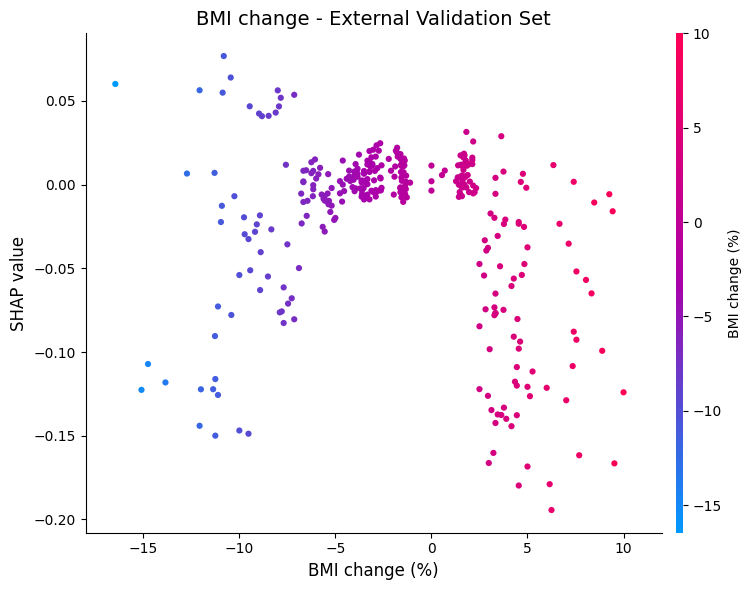

In [32]:
# BMI change
bmi_change_train_df = plot_catboost_dependence(
    shap_values=shap_values_train,
    raw_values=shap_bundle["X_train"]["BMI_change"].values,
    feature_name="BMI change",
    title="BMI change - Training Set",
    x_label="BMI change (%)",
    feature_type="continuous",
    xlim=(-18, 12),
    xticks=range(-15, 11, 5),
)

bmi_change_internal_df = plot_catboost_dependence(
    shap_values=shap_values_intest,
    raw_values=shap_bundle["X_internal"]["BMI_change"].values,
    feature_name="BMI change",
    title="BMI change - Internal Validation Set",
    x_label="BMI change (%)",
    feature_type="continuous",
    xlim=(-18, 12),
    xticks=range(-15, 11, 5),
)

bmi_change_external_df = plot_catboost_dependence(
    shap_values=shap_values_external,
    raw_values=shap_bundle["X_external"]["BMI_change"].values,
    feature_name="BMI change",
    title="BMI change - External Validation Set",
    x_label="BMI change (%)",
    feature_type="continuous",
    xlim=(-18, 12),
    xticks=range(-15, 11, 5),
)

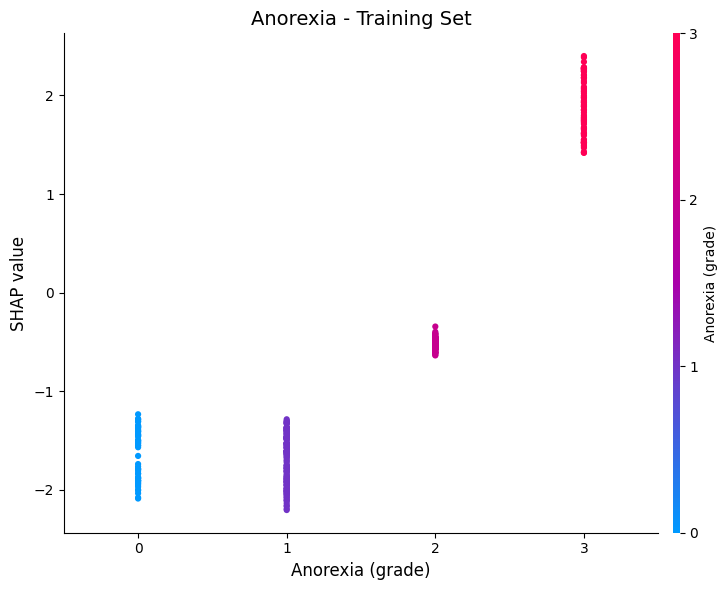

In [29]:
# Anorexia
anorexia_train_df = plot_catboost_dependence(
    shap_values=shap_values_train,
    raw_values=shap_bundle["X_train"]["Anorexia"].values,
    feature_name="Anorexia",
    title="Anorexia - Training Set",
    x_label="Anorexia (grade)",
    colorbar_label="Anorexia (grade)",
    feature_type="categorical",
    xlim=(-0.5, 3.5),
    xticks=[0, 1, 2, 3],
    xtick_labels=["0", "1", "2", "3"],
    category_ticks=[0, 1, 2, 3],
    category_labels=["0", "1", "2", "3"],
)

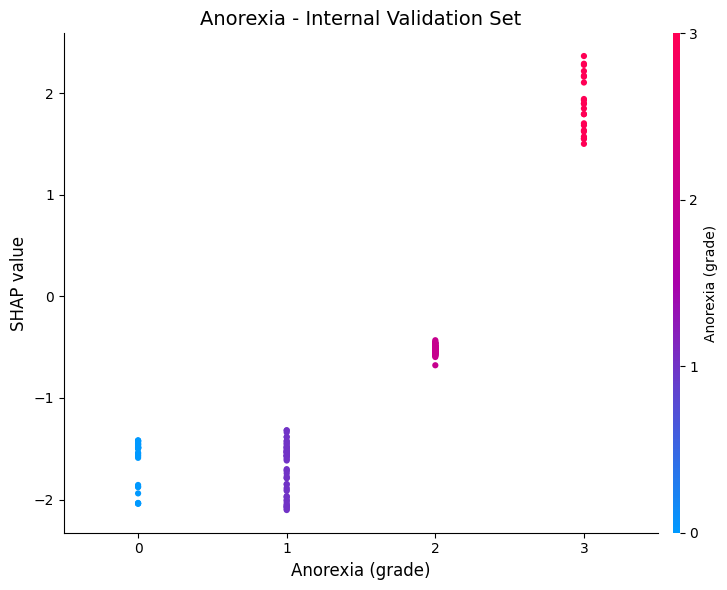

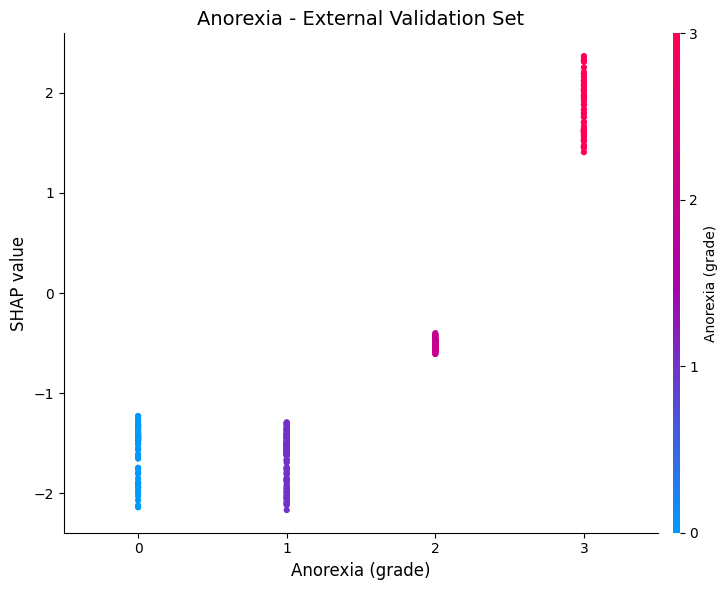

In [30]:
anorexia_internal_df = plot_catboost_dependence(
    shap_values=shap_values_intest,
    raw_values=shap_bundle["X_internal"]["Anorexia"].values,
    feature_name="Anorexia",
    title="Anorexia - Internal Validation Set",
    x_label="Anorexia (grade)",
    colorbar_label="Anorexia (grade)",
    feature_type="categorical",
    xlim=(-0.5, 3.5),
    xticks=[0, 1, 2, 3],
    xtick_labels=["0", "1", "2", "3"],
    category_ticks=[0, 1, 2, 3],
    category_labels=["0", "1", "2", "3"],
)

anorexia_external_df = plot_catboost_dependence(
    shap_values=shap_values_external,
    raw_values=shap_bundle["X_external"]["Anorexia"].values,
    feature_name="Anorexia",
    title="Anorexia - External Validation Set",
    x_label="Anorexia (grade)",
    colorbar_label="Anorexia (grade)",
    feature_type="categorical",
    xlim=(-0.5, 3.5),
    xticks=[0, 1, 2, 3],
    xtick_labels=["0", "1", "2", "3"],
    category_ticks=[0, 1, 2, 3],
    category_labels=["0", "1", "2", "3"],
)

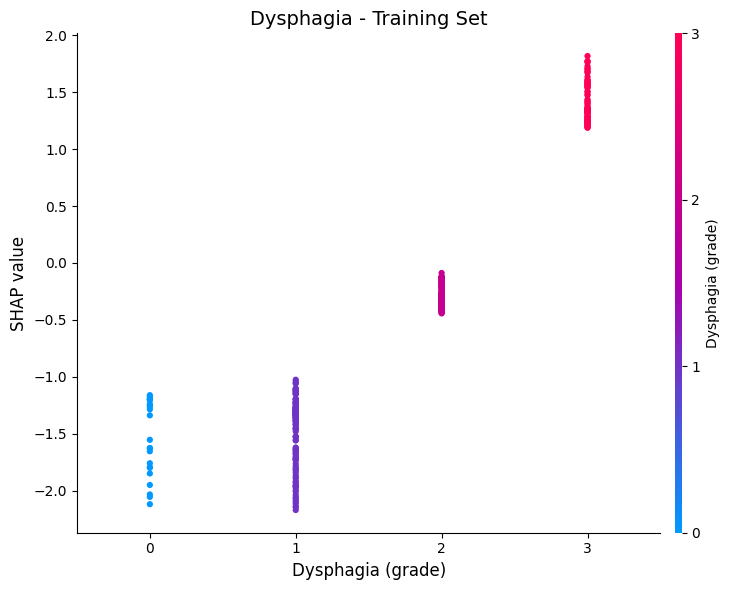

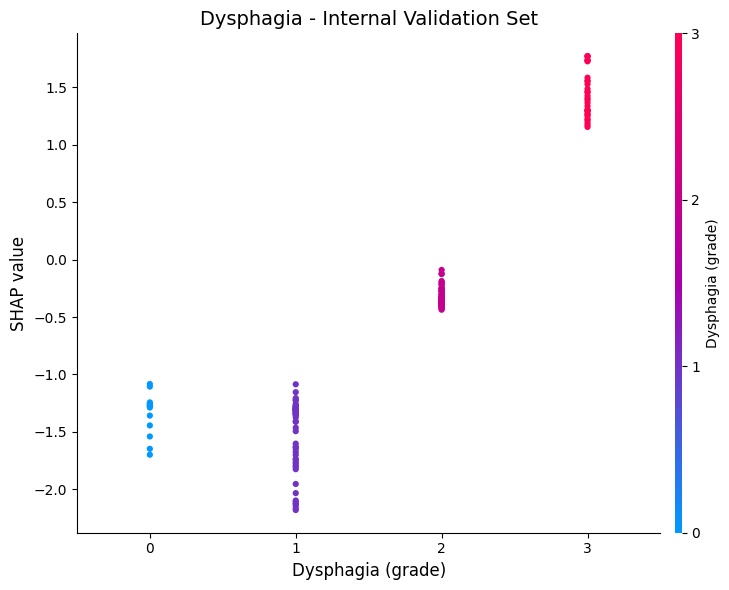

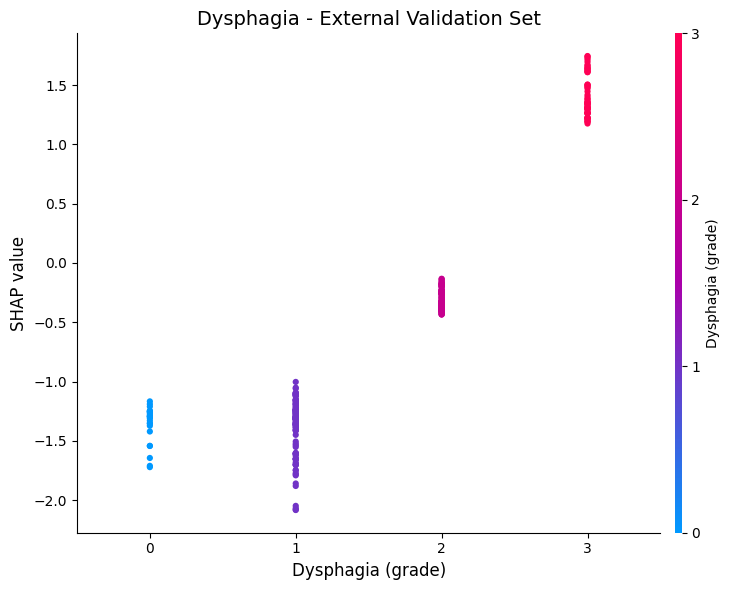

In [33]:
# Dysphagia
dysphagia_train_df = plot_catboost_dependence(
    shap_values=shap_values_train,
    raw_values=shap_bundle["X_train"]["Dysphagia"].values,
    feature_name="Dysphagia",
    title="Dysphagia - Training Set",
    x_label="Dysphagia (grade)",
    colorbar_label="Dysphagia (grade)",
    feature_type="categorical",
    xlim=(-0.5, 3.5),
    xticks=[0, 1, 2, 3],
    xtick_labels=["0", "1", "2", "3"],
    category_ticks=[0, 1, 2, 3],
    category_labels=["0", "1", "2", "3"],
)

dysphagia_internal_df = plot_catboost_dependence(
    shap_values=shap_values_intest,
    raw_values=shap_bundle["X_internal"]["Dysphagia"].values,
    feature_name="Dysphagia",
    title="Dysphagia - Internal Validation Set",
    x_label="Dysphagia (grade)",
    colorbar_label="Dysphagia (grade)",
    feature_type="categorical",
    xlim=(-0.5, 3.5),
    xticks=[0, 1, 2, 3],
    xtick_labels=["0", "1", "2", "3"],
    category_ticks=[0, 1, 2, 3],
    category_labels=["0", "1", "2", "3"],
)

dysphagia_external_df = plot_catboost_dependence(
    shap_values=shap_values_external,
    raw_values=shap_bundle["X_external"]["Dysphagia"].values,
    feature_name="Dysphagia",
    title="Dysphagia - External Validation Set",
    x_label="Dysphagia (grade)",
    colorbar_label="Dysphagia (grade)",
    feature_type="categorical",
    xlim=(-0.5, 3.5),
    xticks=[0, 1, 2, 3],
    xtick_labels=["0", "1", "2", "3"],
    category_ticks=[0, 1, 2, 3],
    category_labels=["0", "1", "2", "3"],
)


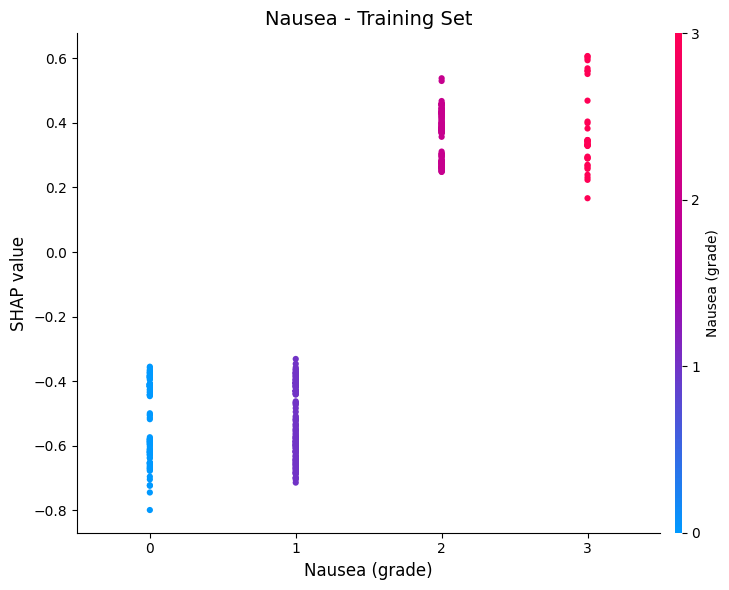

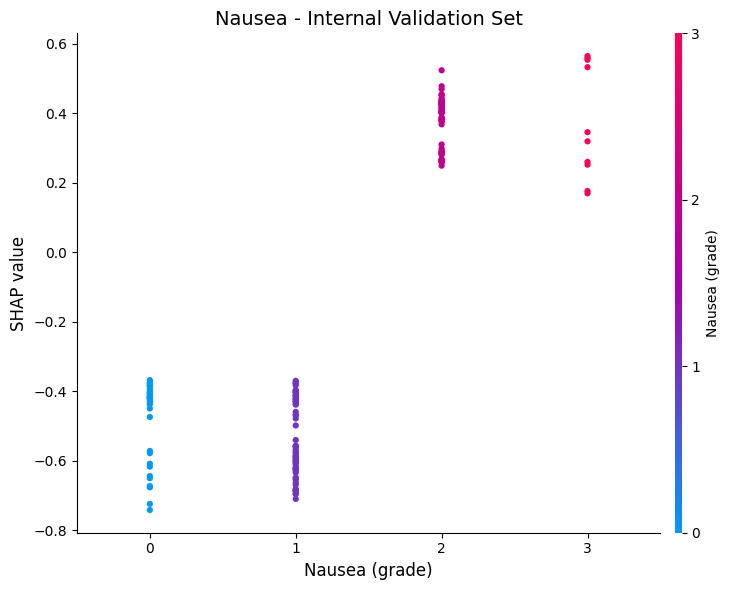

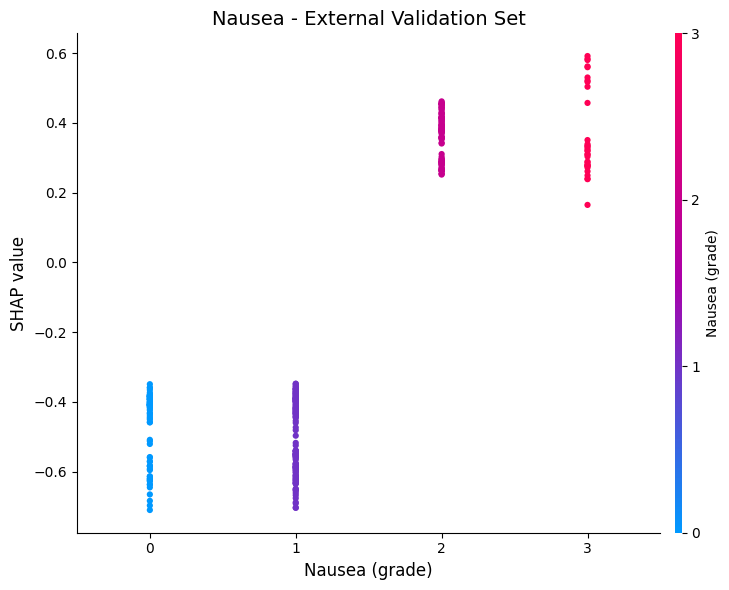

In [34]:
# Nausea
nausea_train_df = plot_catboost_dependence(
    shap_values=shap_values_train,
    raw_values=shap_bundle["X_train"]["Nausea"].values,
    feature_name="Nausea",
    title="Nausea - Training Set",
    x_label="Nausea (grade)",
    colorbar_label="Nausea (grade)",
    feature_type="categorical",
    xlim=(-0.5, 3.5),
    xticks=[0, 1, 2, 3],
    xtick_labels=["0", "1", "2", "3"],
    category_ticks=[0, 1, 2, 3],
    category_labels=["0", "1", "2", "3"],
)

nausea_internal_df = plot_catboost_dependence(
    shap_values=shap_values_intest,
    raw_values=shap_bundle["X_internal"]["Nausea"].values,
    feature_name="Nausea",
    title="Nausea - Internal Validation Set",
    x_label="Nausea (grade)",
    colorbar_label="Nausea (grade)",
    feature_type="categorical",
    xlim=(-0.5, 3.5),
    xticks=[0, 1, 2, 3],
    xtick_labels=["0", "1", "2", "3"],
    category_ticks=[0, 1, 2, 3],
    category_labels=["0", "1", "2", "3"],
)

nausea_external_df = plot_catboost_dependence(
    shap_values=shap_values_external,
    raw_values=shap_bundle["X_external"]["Nausea"].values,
    feature_name="Nausea",
    title="Nausea - External Validation Set",
    x_label="Nausea (grade)",
    colorbar_label="Nausea (grade)",
    feature_type="categorical",
    xlim=(-0.5, 3.5),
    xticks=[0, 1, 2, 3],
    xtick_labels=["0", "1", "2", "3"],
    category_ticks=[0, 1, 2, 3],
    category_labels=["0", "1", "2", "3"],
)

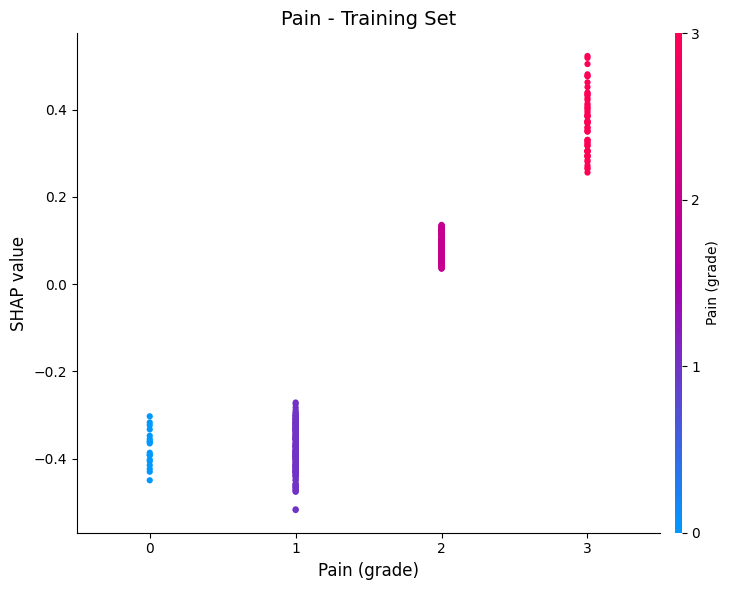

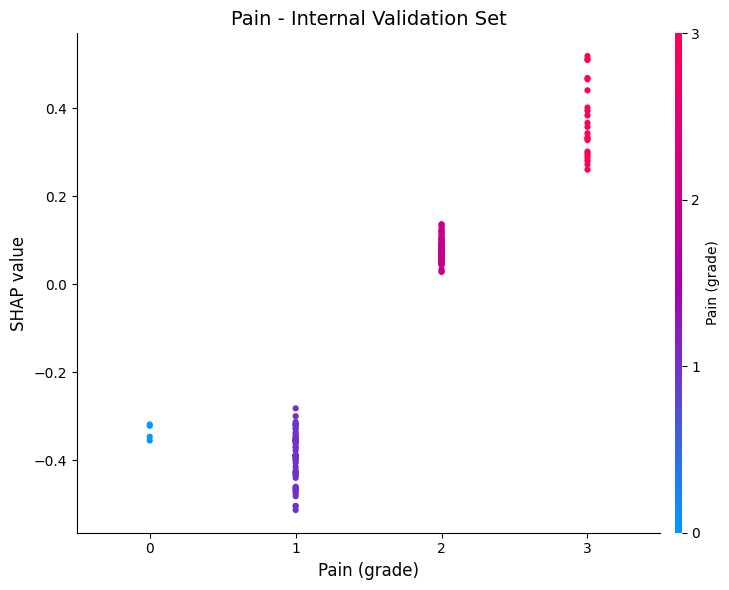

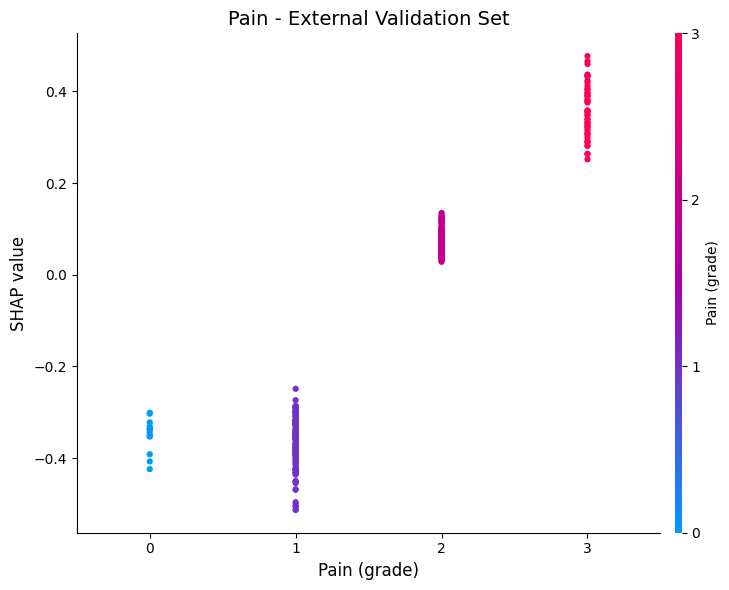

In [35]:
#Pain
pain_train_df = plot_catboost_dependence(
    shap_values=shap_values_train,
    raw_values=shap_bundle["X_train"]["Pain"].values,
    feature_name="Pain",
    title="Pain - Training Set",
    x_label="Pain (grade)",
    colorbar_label="Pain (grade)",
    feature_type="categorical",
    xlim=(-0.5, 3.5),
    xticks=[0, 1, 2, 3],
    xtick_labels=["0", "1", "2", "3"],
    category_ticks=[0, 1, 2, 3],
    category_labels=["0", "1", "2", "3"],
)

pain_internal_df = plot_catboost_dependence(
    shap_values=shap_values_intest,
    raw_values=shap_bundle["X_internal"]["Pain"].values,
    feature_name="Pain",
    title="Pain - Internal Validation Set",
    x_label="Pain (grade)",
    colorbar_label="Pain (grade)",
    feature_type="categorical",
    xlim=(-0.5, 3.5),
    xticks=[0, 1, 2, 3],
    xtick_labels=["0", "1", "2", "3"],
    category_ticks=[0, 1, 2, 3],
    category_labels=["0", "1", "2", "3"],
)

pain_external_df = plot_catboost_dependence(
    shap_values=shap_values_external,
    raw_values=shap_bundle["X_external"]["Pain"].values,
    feature_name="Pain",
    title="Pain - External Validation Set",
    x_label="Pain (grade)",
    colorbar_label="Pain (grade)",
    feature_type="categorical",
    xlim=(-0.5, 3.5),
    xticks=[0, 1, 2, 3],
    xtick_labels=["0", "1", "2", "3"],
    category_ticks=[0, 1, 2, 3],
    category_labels=["0", "1", "2", "3"],
)

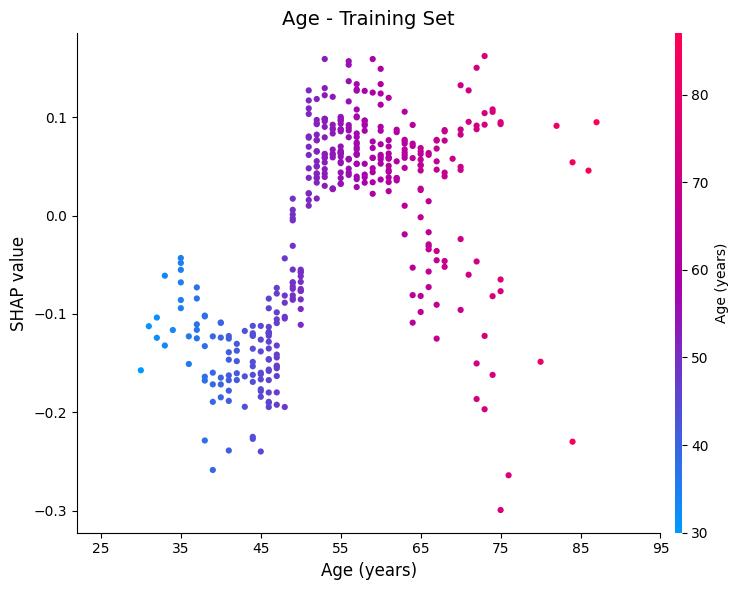

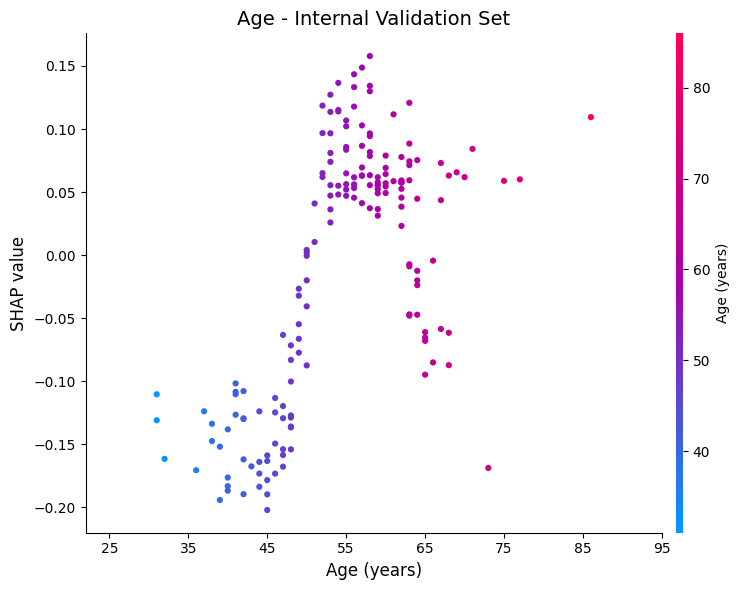

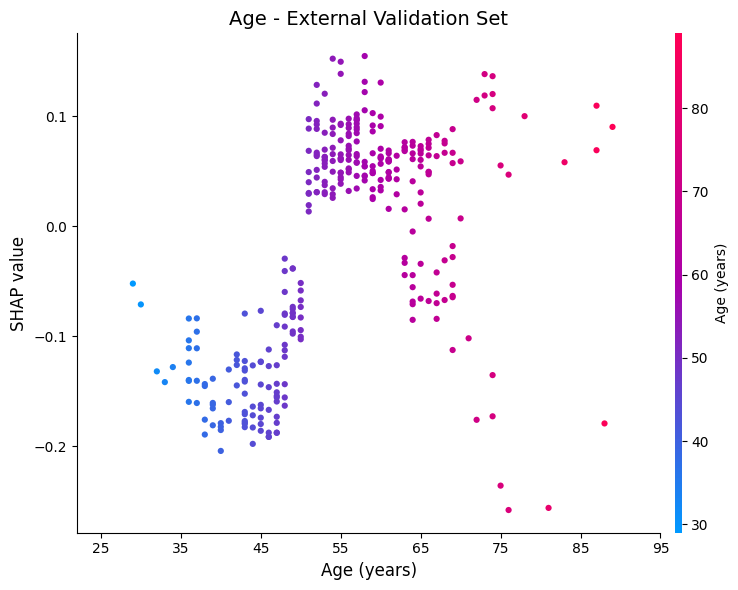

In [36]:
#Age
age_train_df = plot_catboost_dependence(
    shap_values=shap_values_train,
    raw_values=shap_bundle["X_train"]["Age"].values,
    feature_name="Age",
    title="Age - Training Set",
    x_label="Age (years)",
    feature_type="continuous",
    xlim=(22, 95),
    xticks=range(25, 96, 10),
)

age_internal_df = plot_catboost_dependence(
    shap_values=shap_values_intest,
    raw_values=shap_bundle["X_internal"]["Age"].values,
    feature_name="Age",
    title="Age - Internal Validation Set",
    x_label="Age (years)",
    feature_type="continuous",
    xlim=(22, 95),
    xticks=range(25, 96, 10),
)

age_external_df = plot_catboost_dependence(
    shap_values=shap_values_external,
    raw_values=shap_bundle["X_external"]["Age"].values,
    feature_name="Age",
    title="Age - External Validation Set",
    x_label="Age (years)",
    feature_type="continuous",
    xlim=(22, 95),
    xticks=range(25, 96, 10),
)

# force plot

In [37]:
import os
import numpy as np
import pandas as pd
import shap
from scipy.special import expit
from IPython.display import display
# 初始化 SHAP 的 JavaScript
shap.initjs()
# 定義 SHAP 圖表中顯示的特徵名稱
custom_feature_names = [
    "Age", "Pre-BMI", "BMI change", "Pre-SMI", "Sex", "ECOG", "Tumor site",
    "Stage", "Chemotherapy", "Smoking", "Dermatitis", "Mucositis",
    "Xerostomia", "Dysphagia", "Pain", "Anorexia", "Nausea", "Fatigue"
]
# 定義原始資料中的特徵欄位名稱
original_feature_names = [
    "Age", "pre_BMI", "BMI_change", "pre_SMI", "Sex", "ECOG", "Tumor_site",
    "Stage", "Chemotherapy", "Smoking", "Dermatitis", "Mucositis",
    "Xerostomia", "Dysphagia", "Pain", "Anorexia", "Nausea", "Fatigue"
]
# 定義需要以連續數值格式顯示的特徵
continuous_display_names = ["Age", "Pre-BMI", "BMI change", "Pre-SMI"]

In [48]:
# 為每位研究對象建立 SHAP force plot 並輸出為 HTML
def create_catboost_forceplots(shap_values, raw_data, subject_ids, dataset_title, out_html,
                               sort_by_abs=False, batch_k=0, batch_size=400, display_plots=True):
    # 建立 HTML 輸出資料夾
    os.makedirs(os.path.dirname(out_html) or ".", exist_ok=True)
    # 依指定順序取得原始特徵，並更換為圖表顯示名稱
    X_raw = raw_data[original_feature_names].copy()
    X_raw.columns = custom_feature_names
    subject_ids = np.asarray(subject_ids)
    # 檢查特徵資料與研究對象 ID 的筆數是否一致
    if len(X_raw) != len(subject_ids):
        raise ValueError(f"特徵資料有 {len(X_raw)} 筆，但 Subject ID 有 {len(subject_ids)} 筆")
    # 檢查 SHAP 結果是否足以對應所有研究對象
    if len(shap_values.values) < len(X_raw):
        raise ValueError(f"SHAP 只有 {len(shap_values.values)} 筆，但資料有 {len(X_raw)} 筆")
    # 建立 HTML 文件的基本架構、JavaScript 及版面樣式
    html_parts = [
        "<!DOCTYPE html><html><head><meta charset='utf-8'>",
        "<script src='https://cdnjs.cloudflare.com/ajax/libs/require.js/2.3.6/require.min.js'></script>",
        shap.getjs(),
        """<style>
        body { font-family: Arial, sans-serif; margin: 16px; }
        .card { margin: 20px auto; padding: 12px 16px; border: 1px solid #ddd; border-radius: 10px; max-width: 1280px; }
        .title { font-size: 16px; font-weight: 600; margin-bottom: 8px; }
        .sep { height: 1px; background: #eee; margin: 12px 0; }
        </style></head><body>"""
    ]
    # 根據批次編號與批次大小決定本次處理的資料範圍
    start_idx = batch_k * batch_size
    end_idx = min(start_idx + batch_size, len(X_raw))
    n_outputs = 0
    # 逐一建立每位研究對象的 SHAP force plot
    for i in range(start_idx, end_idx):
        # 取得該研究對象的 SHAP 值、基準值及原始特徵值
        ex = shap_values[i]
        shap_vals = np.asarray(ex.values)
        base_value = float(np.asarray(ex.base_values).reshape(-1)[0])
        row_values = X_raw.iloc[i].to_numpy()
        feature_names = list(custom_feature_names)
        # 將模型的 log-odds 轉換為預測機率
        probability = float(expit(base_value + shap_vals.sum()))
        # 若有指定，依照 SHAP 絕對值由大至小排列特徵
        if sort_by_abs:
            order = np.argsort(np.abs(shap_vals))[::-1]
            shap_vals = shap_vals[order]
            row_values = row_values[order]
            feature_names = [feature_names[j] for j in order]
        # 根據特徵類型設定 force plot 中的數值顯示格式
        feature_labels = [
            f"{name} = {int(value)}" if name == "Age"
            else f"{name} = {value:.1f}" if name in continuous_display_names
            else f"{name} = {int(value)}"
            for name, value in zip(feature_names, row_values)
        ]

        if display_plots:
            display(shap.force_plot(base_value, shap_vals, feature_labels, link="logit"))

        vis = shap.force_plot(base_value, shap_vals, feature_labels, link="logit", show=False)
        subject_id = subject_ids[i]

        html_parts += [
            '<div class="card">',
            f'<div class="title">Subject ID = {int(subject_id)} | Predicted probability = {probability:.3f}</div>',
            '<div class="sep"></div>',
            vis.html(),
            '</div>'
        ]

        n_outputs += 1
        print(f"✅ Subject ID = {int(subject_id)} | Predicted probability = {probability:.3f}")

    html_parts.insert(4, f"<h2>SHAP Force Plots — {dataset_title}（共 {n_outputs} 筆）</h2>")
    html_parts.append("</body></html>")

    with open(out_html, "w", encoding="utf-8") as file:
        file.write("".join(html_parts))

    print(f"\n最終輸出 SHAP force plot 數量：{n_outputs}")
    print(f"📄 HTML 檔案已儲存：{out_html}")

    return out_html

In [49]:
train_set = pd.read_excel(data_file, sheet_name="Train")
internal_test_set = pd.read_excel(data_file, sheet_name="InternalTest")
External_set = pd.read_excel(data_file, sheet_name="ExternalTest")

shap_bundle["train_ids"] = train_set["ID"].to_numpy()
shap_bundle["internal_ids"] = internal_test_set["ID"].to_numpy()
shap_bundle["external_ids"] = External_set["ID"].to_numpy()

print("Subject ID 已載入")

Subject ID 已載入


In [50]:
shap_bundle["train_ids"] = train_set["ID"].to_numpy()
shap_bundle["internal_ids"] = internal_test_set["ID"].to_numpy()
shap_bundle["external_ids"] = External_set["ID"].to_numpy()

In [51]:
# Training Set
train_force_html = create_catboost_forceplots(
    shap_values=shap_values_train,
    raw_data=shap_bundle["X_train"],
    subject_ids=shap_bundle["train_ids"],
    dataset_title="Train Set",
    out_html="shap_force_all_in_one_final2/forceplots_train_set2_smotenc.html",
    sort_by_abs=False,
    batch_k=0,
    batch_size=400,
    display_plots=False,
)

✅ Subject ID = 99993 | Predicted probability = 0.289
✅ Subject ID = 99994 | Predicted probability = 0.359
✅ Subject ID = 99995 | Predicted probability = 0.038
✅ Subject ID = 99998 | Predicted probability = 0.025
✅ Subject ID = 99999 | Predicted probability = 0.037
✅ Subject ID = 100001 | Predicted probability = 0.055
✅ Subject ID = 100002 | Predicted probability = 0.038
✅ Subject ID = 100003 | Predicted probability = 0.028
✅ Subject ID = 100004 | Predicted probability = 0.978
✅ Subject ID = 100005 | Predicted probability = 0.061
✅ Subject ID = 100007 | Predicted probability = 0.088
✅ Subject ID = 100013 | Predicted probability = 0.044
✅ Subject ID = 100015 | Predicted probability = 0.027
✅ Subject ID = 100016 | Predicted probability = 0.074
✅ Subject ID = 100017 | Predicted probability = 0.036
✅ Subject ID = 100018 | Predicted probability = 0.072
✅ Subject ID = 100021 | Predicted probability = 0.044
✅ Subject ID = 100023 | Predicted probability = 0.146
✅ Subject ID = 100024 | Predicted

In [52]:
# Internal Validation Set"
internal_force_html = create_catboost_forceplots(
    shap_values=shap_values_intest,
    raw_data=shap_bundle["X_internal"],
    subject_ids=shap_bundle["internal_ids"],
    dataset_title="Internal Test Set",
    out_html="shap_force_internal_test_final2/forceplots_internal_test_set2_smotenc.html",
    sort_by_abs=True,
    batch_k=0,
    batch_size=400,
    display_plots=False,
)

✅ Subject ID = 99991 | Predicted probability = 0.037
✅ Subject ID = 99992 | Predicted probability = 0.045
✅ Subject ID = 99997 | Predicted probability = 0.033
✅ Subject ID = 100008 | Predicted probability = 0.024
✅ Subject ID = 100009 | Predicted probability = 0.101
✅ Subject ID = 100010 | Predicted probability = 0.126
✅ Subject ID = 100012 | Predicted probability = 0.303
✅ Subject ID = 100019 | Predicted probability = 0.290
✅ Subject ID = 100027 | Predicted probability = 0.101
✅ Subject ID = 100028 | Predicted probability = 0.077
✅ Subject ID = 100029 | Predicted probability = 0.055
✅ Subject ID = 100033 | Predicted probability = 0.862
✅ Subject ID = 100037 | Predicted probability = 0.036
✅ Subject ID = 100038 | Predicted probability = 0.192
✅ Subject ID = 100042 | Predicted probability = 0.917
✅ Subject ID = 100051 | Predicted probability = 0.108
✅ Subject ID = 100058 | Predicted probability = 0.072
✅ Subject ID = 100070 | Predicted probability = 0.077
✅ Subject ID = 100072 | Predict

In [53]:
# External Validation Set"
external_force_html = create_catboost_forceplots(
    shap_values=shap_values_external,
    raw_data=shap_bundle["X_external"],
    subject_ids=shap_bundle["external_ids"],
    dataset_title="External Test Set",
    out_html="shap_force_external_test_final2/forceplots_external_test_set2_smotenc.html",
    sort_by_abs=True,
    batch_k=0,
    batch_size=400,
    display_plots=False,
)

✅ Subject ID = 1 | Predicted probability = 0.025
✅ Subject ID = 3 | Predicted probability = 0.029
✅ Subject ID = 4 | Predicted probability = 0.026
✅ Subject ID = 5 | Predicted probability = 0.268
✅ Subject ID = 6 | Predicted probability = 0.032
✅ Subject ID = 7 | Predicted probability = 0.035
✅ Subject ID = 8 | Predicted probability = 0.041
✅ Subject ID = 9 | Predicted probability = 0.072
✅ Subject ID = 10 | Predicted probability = 0.466
✅ Subject ID = 11 | Predicted probability = 0.911
✅ Subject ID = 12 | Predicted probability = 0.029
✅ Subject ID = 13 | Predicted probability = 0.031
✅ Subject ID = 14 | Predicted probability = 0.846
✅ Subject ID = 15 | Predicted probability = 0.025
✅ Subject ID = 16 | Predicted probability = 0.025
✅ Subject ID = 17 | Predicted probability = 0.272
✅ Subject ID = 18 | Predicted probability = 0.053
✅ Subject ID = 20 | Predicted probability = 0.039
✅ Subject ID = 22 | Predicted probability = 0.083
✅ Subject ID = 23 | Predicted probability = 0.068
✅ Subjec

## 有labal

In [54]:
import os
import numpy as np
import pandas as pd
import shap
from scipy.special import expit
from IPython.display import display

shap.initjs()
# 根據真實與預測標籤判定分類結果
def get_classification_result(y_true, y_pred):
    if y_true == 1 and y_pred == 1:
        return "TP"
    if y_true == 0 and y_pred == 1:
        return "FP"
    if y_true == 0 and y_pred == 0:
        return "TN"
    return "FN"

In [55]:
def create_catboost_forceplots_with_results(
    shap_values, raw_data, subject_ids, y_true, dataset_title, out_html,
    threshold=0.5, sort_by_abs=True, batch_k=0, batch_size=400, display_plots=True
):
    os.makedirs(os.path.dirname(out_html) or ".", exist_ok=True)

    custom_names = [
        "Age", "Pre-BMI", "BMI change", "Pre-SMI", "Sex", "ECOG", "Tumor site",
        "Stage", "Chemotherapy", "Smoking", "Dermatitis", "Mucositis",
        "Xerostomia", "Dysphagia", "Pain", "Anorexia", "Nausea", "Fatigue"
    ]
    original_names = [
        "Age", "pre_BMI", "BMI_change", "pre_SMI", "Sex", "ECOG", "Tumor_site",
        "Stage", "Chemotherapy", "Smoking", "Dermatitis", "Mucositis",
        "Xerostomia", "Dysphagia", "Pain", "Anorexia", "Nausea", "Fatigue"
    ]
    continuous_names = ["Age", "Pre-BMI", "BMI change", "Pre-SMI"]

    X_raw = raw_data[original_names].copy()
    X_raw.columns = custom_names
    subject_ids, y_true = np.asarray(subject_ids), np.asarray(y_true).astype(int)

    if not (len(X_raw) == len(subject_ids) == len(y_true)):
        raise ValueError("raw_data、subject_ids、y_true 的資料筆數不一致")
    if len(shap_values.values) < len(X_raw):
        raise ValueError("SHAP values 的資料筆數少於 raw_data")

    html_parts = [
        "<!DOCTYPE html><html><head><meta charset='utf-8'>",
        "<script src='https://cdnjs.cloudflare.com/ajax/libs/require.js/2.3.6/require.min.js'></script>",
        shap.getjs(),
        """<style>
        body { font-family: Arial, sans-serif; margin: 16px; }
        .card { margin: 20px auto; padding: 12px 16px; border: 1px solid #ddd; border-radius: 10px; max-width: 1280px; }
        .title { font-size: 16px; font-weight: 600; margin-bottom: 8px; }
        .sep { height: 1px; background: #eee; margin: 12px 0; }
        </style></head><body>"""
    ]

    start_idx, end_idx = batch_k * batch_size, min((batch_k + 1) * batch_size, len(X_raw))
    prediction_records = []
    # 逐一建立每位研究對象的 SHAP force plot
    for i in range(start_idx, end_idx):
        # 取得該研究對象的 SHAP 值、基準值及原始特徵值
        ex = shap_values[i]
        shap_vals = np.asarray(ex.values)
        base_value = float(np.asarray(ex.base_values).reshape(-1)[0])
        feature_names = list(custom_names)
        row_values = X_raw.iloc[i].to_numpy()
        # 將模型輸出轉換為預測機率，並依閾值產生預測標籤
        probability = float(expit(base_value + shap_vals.sum()))
        predicted_label = int(probability >= threshold)
        true_label = int(y_true[i])
        # 判定該筆預測屬於 TP、FP、TN 或 FN
        result = get_classification_result(true_label, predicted_label)

        if sort_by_abs:
            order = np.argsort(np.abs(shap_vals))[::-1]
            shap_vals, row_values = shap_vals[order], row_values[order]
            feature_names = [feature_names[j] for j in order]

        feature_labels = [
            f"{name} = {int(value)}" if name == "Age"
            else f"{name} = {value:.1f}" if name in continuous_names
            else f"{name} = {int(value)}"
            for name, value in zip(feature_names, row_values)
        ]

        if display_plots:
            display(shap.force_plot(base_value, shap_vals, feature_labels, link="logit"))

        vis = shap.force_plot(base_value, shap_vals, feature_labels, link="logit", show=False)
        subject_id = subject_ids[i]

        html_parts += [
            '<div class="card">',
            f'<div class="title">Subject ID = {int(subject_id)} | Pred prob = {probability:.3f} | '
            f'True = {true_label} | Pred = {predicted_label} → <b>{result}</b></div>',
            '<div class="sep"></div>', vis.html(), '</div>'
        ]

        prediction_records.append({
            "Subject_ID": subject_id,
            "y_true": true_label,
            "y_prob": probability,
            "y_pred": predicted_label,
            "Result": result
        })

        print(f"✅ Subject ID = {int(subject_id)} | Pred prob = {probability:.3f} | "
              f"True = {true_label} | Pred = {predicted_label} → {result}")

    html_parts.insert(4, f"<h2>SHAP Force Plots — {dataset_title}（共 {len(prediction_records)} 筆）</h2>")
    html_parts.append("</body></html>")

    with open(out_html, "w", encoding="utf-8") as file:
        file.write("\n".join(html_parts))

    predictions_df = pd.DataFrame(prediction_records)
    print(f"\n Force plots HTML 已輸出到：{out_html}")
    return predictions_df

In [ ]:
# Training Set
train_force_results = create_catboost_forceplots_with_results(
    shap_values=shap_values_train,
    raw_data=shap_bundle["X_train"],
    subject_ids=shap_bundle["train_ids"],
    y_true=shap_bundle["y_train"],
    dataset_title="Train Set",
    out_html="shap_force_train_final_18features/forceplots_train_set_18features_smotenc.html",
    threshold=0.5,
    sort_by_abs=False,
    batch_k=0,
    batch_size=400,
    display_plots=True,
)

In [ ]:
# Internal Validation Set"
internal_force_results = create_catboost_forceplots_with_results(
    shap_values=shap_values_intest,
    raw_data=shap_bundle["X_internal"],
    subject_ids=shap_bundle["internal_ids"],
    y_true=shap_bundle["y_internal"],
    dataset_title="Internal Test Set",
    out_html="shap_force_internal_test_final_18features/forceplots_internal_test_set_18features_smotenc.html",
    threshold=0.5,
    sort_by_abs=True,
    batch_k=0,
    batch_size=400,
    display_plots=True,
)

In [ ]:
# External Validation Set"
external_force_results = create_catboost_forceplots_with_results(
    shap_values=shap_values_external,
    raw_data=shap_bundle["X_external"],
    subject_ids=shap_bundle["external_ids"],
    y_true=shap_bundle["y_external"],
    dataset_title="External Test Set",
    out_html="shap_force_external_test_final_18features/forceplots_external_test_set_18features_smotenc.html",
    threshold=0.5,
    sort_by_abs=True,
    batch_k=0,
    batch_size=400,
    display_plots=True,
)